# Generative Adversarial Networks (GAN)

## Importing the libraries

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tqdm import tqdm
from tensorflow import keras
from tensorflow.keras import layers

## Importing the dataset

In [2]:
import kagglehub

In [3]:
path = kagglehub.dataset_download("splcher/animefacedataset")
print(path)

Using Colab cache for faster access to the 'animefacedataset' dataset.
/kaggle/input/animefacedataset


## Locating Images

In [4]:
image_paths = []

for root, dirs, files in os.walk(path):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            image_paths.append(os.path.join(root, file))

print(f"Total Images: {len(image_paths)}")
print(image_paths[:5])

Total Images: 63565
['/kaggle/input/animefacedataset/images/35715_2011.jpg', '/kaggle/input/animefacedataset/images/48610_2014.jpg', '/kaggle/input/animefacedataset/images/34719_2011.jpg', '/kaggle/input/animefacedataset/images/40266_2012.jpg', '/kaggle/input/animefacedataset/images/4199_2002.jpg']


## Creating TensorFlow Dataset

In [5]:
IMAGE_SIZE = 64
BATCH_SIZE = 64
AUTOTUNE = tf.data.AUTOTUNE

In [6]:
def load_image(image_path):

    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, (IMAGE_SIZE, IMAGE_SIZE))
    image = tf.cast(image, tf.float32)
    image = (image - 127.5) / 127.5

    return image

In [7]:
dataset = (
    tf.data.Dataset.from_tensor_slices(image_paths)
    .shuffle(len(image_paths))
    .map(load_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

## Visualizing Dataset

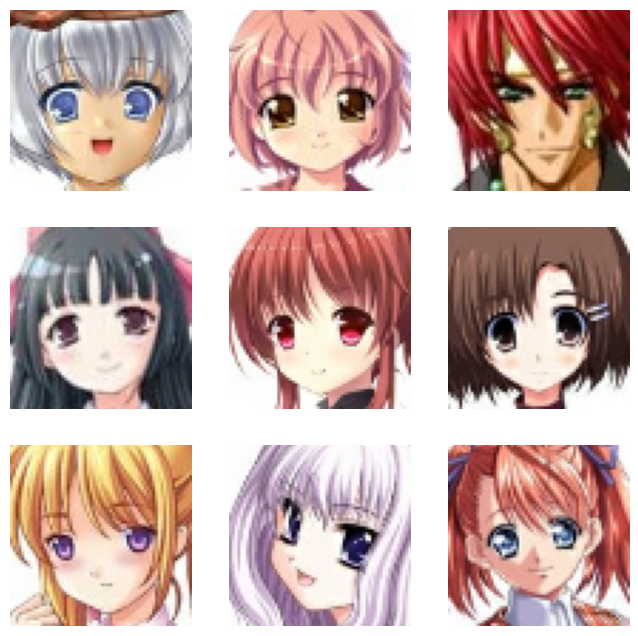

In [8]:
plt.figure(figsize = (8, 8))

for images in dataset.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow((images[i] + 1) / 2)
        plt.axis("off")

plt.show()

## Creating Generator

In [9]:
LATENT_DIM = 100

In [10]:
generator = keras.Sequential([

    layers.Dense(8 * 8 * 256, use_bias = False, input_shape = (LATENT_DIM, )),
    layers.BatchNormalization(),
    layers.LeakyReLU(),

    layers.Reshape((8, 8, 256)),

    layers.Conv2DTranspose(
        128,
        kernel_size = 4,
        strides = 2,
        padding = "same",
        use_bias = False
    ),
    layers.BatchNormalization(),
    layers.LeakyReLU(),

    layers.Conv2DTranspose(
        64,
        kernel_size = 4,
        strides = 2,
        padding = "same",
        use_bias = False
    ),
    layers.BatchNormalization(),
    layers.LeakyReLU(),

    layers.Conv2DTranspose(
        3,
        kernel_size = 4,
        strides = 2,
        padding = "same",
        activation = "tanh"
    )
])

generator.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16384)          │     1,638,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 16384)          │        65,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 16, 16, 128)    │       524,288 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 32, 32, 64)     │       131,072 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 64, 64, 3)      │         3,075 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,363,139 (9.01 MB)

 Trainable params: 2,329,987 (8.89 MB)

 Non-trainable params: 33,152 (129.50 KB)

## Testing Generator

In [11]:
noise = tf.random.normal((1, LATENT_DIM))
generated_image = generator(noise, training = False)
print(generated_image.shape)

(1, 64, 64, 3)


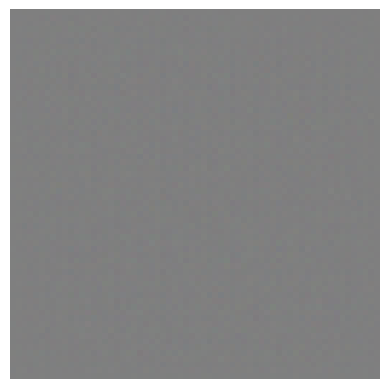

In [12]:
plt.imshow((generated_image[0] + 1) / 2)
plt.axis("off")
plt.show()

## Building the Discriminator

In [13]:
discriminator = keras.Sequential([

    layers.Input(shape = (64, 64, 3)),

    layers.Conv2D(
        64,
        kernel_size = 4,
        strides = 2,
        padding = "same"
    ),
    layers.LeakyReLU(0.2),
    layers.Dropout(0.3),

    layers.Conv2D(
        128,
        kernel_size = 4,
        strides = 2,
        padding = "same"
    ),
    layers.LeakyReLU(0.2),
    layers.Dropout(0.3),

    layers.Conv2D(
        256,
        kernel_size = 4,
        strides = 2,
        padding = "same"
    ),
    layers.LeakyReLU(0.2),
    layers.Dropout(0.3),

    layers.Flatten(),
    layers.Dense(1)
])

discriminator.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 128)    │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 256)      │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │        16,385 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 675,265 (2.58 MB)

 Trainable params: 675,265 (2.58 MB)

 Non-trainable params: 0 (0.00 B)

## Testing the Discriminator

In [14]:
decision = discriminator(generated_image)
print(decision)

tf.Tensor([[0.00086575]], shape=(1, 1), dtype=float32)


## Define the Loss Function

In [15]:
cross_entropy = keras.losses.BinaryCrossentropy(
    from_logits = True
)

## Generator Loss

In [16]:
def generator_loss(fake_output):
    return cross_entropy(
        tf.ones_like(fake_output),
        fake_output
    )

## Discriminator Loss

In [17]:
def discriminator_loss(real_output, fake_output):

    real_loss = cross_entropy(
        tf.ones_like(real_output),
        real_output
    )

    fake_loss = cross_entropy(
        tf.zeros_like(fake_output),
        fake_output
    )

    total_loss = real_loss + fake_loss

    return total_loss

## Optimizers

In [18]:
generator_optimizer = keras.optimizers.Adam(
    learning_rate = 2e-4,
    beta_1 = 0.5
)

discriminator_optimizer = keras.optimizers.Adam(
    learning_rate = 2e-4,
    beta_1 = 0.5
)

## Creating a Fixed Seed

In [19]:
NUM_EXAMPLES = 16

seed = tf.random.normal(
    [NUM_EXAMPLES, LATENT_DIM]
)

## Training Step

In [20]:
@tf.function
def train_step(real_images):

    batch_size = tf.shape(real_images)[0]

    noise = tf.random.normal(
        [batch_size, LATENT_DIM]
    )

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:

        fake_images = generator(
            noise,
            training = True
        )

        real_output = discriminator(
            real_images,
            training = True
        )

        fake_output = discriminator(
            fake_images,
            training = True
        )

        gen_loss = generator_loss(
            fake_output
        )

        disc_loss = discriminator_loss(
            real_output,
            fake_output
        )

    gradients_generator = gen_tape.gradient(
        gen_loss,
        generator.trainable_variables
    )

    gradients_discriminator = disc_tape.gradient(
        disc_loss,
        discriminator.trainable_variables
    )

    generator_optimizer.apply_gradients(
        zip(gradients_generator, generator.trainable_variables)
    )

    discriminator_optimizer.apply_gradients(
        zip(gradients_discriminator, discriminator.trainable_variables)
    )

    return gen_loss, disc_loss

## Function to Generate Images

In [21]:
def generate_images(model, epoch, test_input):

    predictions = model(
        test_input,
        training = False
    )

    plt.figure(figsize = (8, 8))

    for i in range(predictions.shape[0]):

        plt.subplot(4, 4, i + 1)

        image = (predictions[i] + 1) / 2

        plt.imshow(image)
        plt.axis("off")

    plt.suptitle(f"Epoch {epoch}")
    plt.tight_layout()
    plt.show()

## Training Loop

In [22]:
EPOCHS = 50

In [ ]:
for epoch in range(EPOCHS):

    gen_loss_avg = keras.metrics.Mean()
    disc_loss_avg = keras.metrics.Mean()

    for real_images in tqdm(dataset):

        g_loss, d_loss = train_step(
            real_images
        )

        gen_loss_avg.update_state(g_loss)
        disc_loss_avg.update_state(d_loss)

    print(
        f"Epoch {epoch + 1}/{EPOCHS} | "
        f"G Loss: {gen_loss_avg.result():.4f} | "
        f"D Loss: {disc_loss_avg.result():.4f}"
    )

    generate_images(
        generator,
        epoch + 1,
        seed
    )

## Saving the Generator

In [24]:
generator.save("dcgan_generator.keras")
print("Generator saved successfully!")

Generator saved successfully!


## Loading the Generator

In [25]:
generator = keras.models.load_model("dcgan_generator.keras", compile = False)
print("Generator loaded successfully!")

Generator loaded successfully!


## Generating a Single Random Image

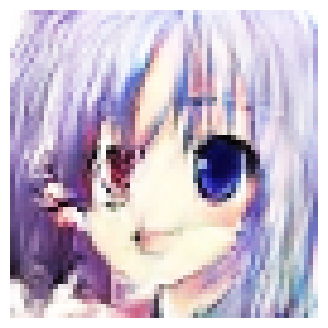

In [26]:
noise = tf.random.normal((1, LATENT_DIM))
generated = generator.predict(noise, verbose=0)
image = (generated[0] + 1) / 2

plt.figure(figsize=(4,4))
plt.imshow(image)
plt.axis("off")
plt.show()

## Generating Multiple Images

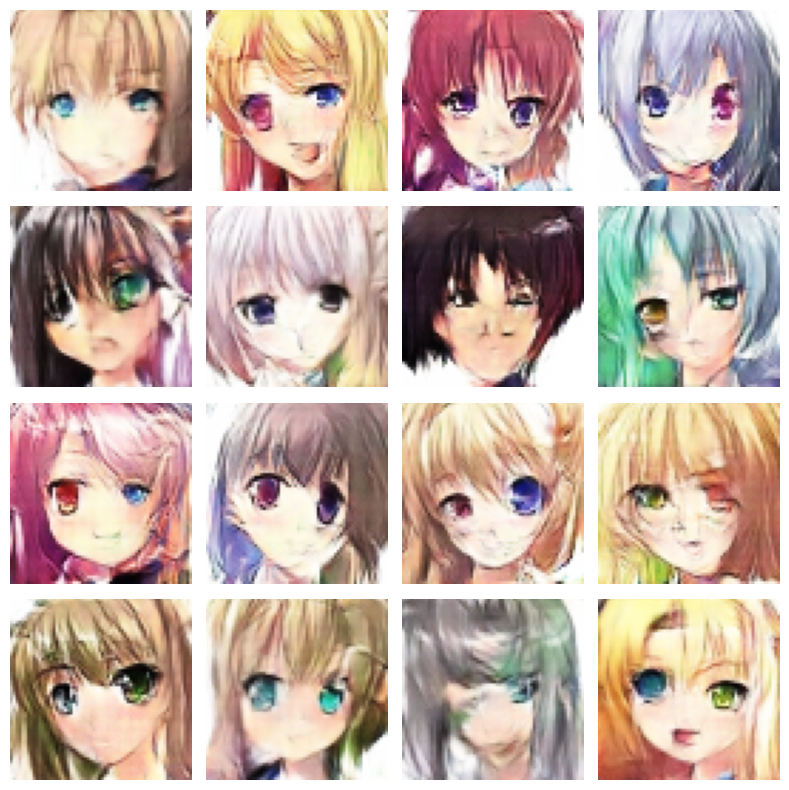

In [27]:
noise = tf.random.normal((16, LATENT_DIM))
generated = generator.predict(noise, verbose = 0)
plt.figure(figsize = (8, 8))

for i in range(16):

    plt.subplot(4, 4, i + 1)
    plt.imshow((generated[i] + 1) / 2)
    plt.axis("off")

plt.tight_layout()
plt.show()

## Image Grid (64 Images)

In [28]:
noise = tf.random.normal((64, LATENT_DIM))
generated = generator.predict(noise, verbose = 0)
plt.figure(figsize = (12, 12))

for i in range(64):

    plt.subplot(8, 8, i + 1)
    plt.imshow((generated[i] + 1) / 2)
    plt.axis("off")

plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

## Latent Space Interpolation

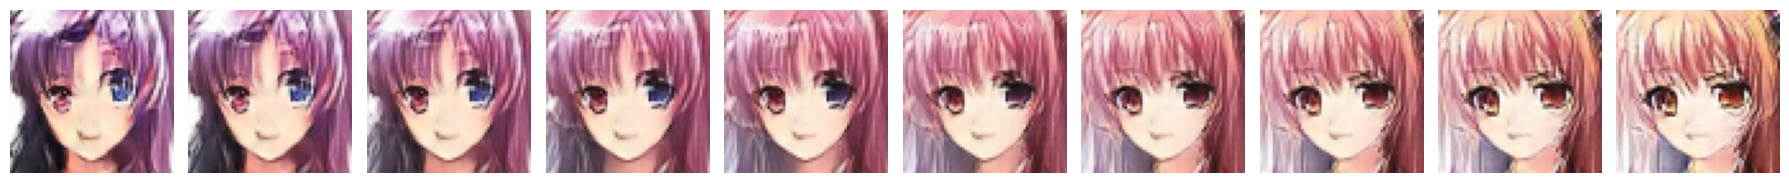

In [29]:
noise1 = tf.random.normal((1, LATENT_DIM))
noise2 = tf.random.normal((1, LATENT_DIM))

alphas = np.linspace(0, 1, 10)
plt.figure(figsize = (18, 2))

for i, alpha in enumerate(alphas):

    z = (1 - alpha) * noise1 + alpha * noise2
    image = generator.predict(z, verbose = 0)[0]
    image = (image + 1) / 2

    plt.subplot(1, 10, i + 1)
    plt.imshow(image)
    plt.axis("off")

plt.tight_layout()
plt.show()

## Generate Images from User-Defined Noise

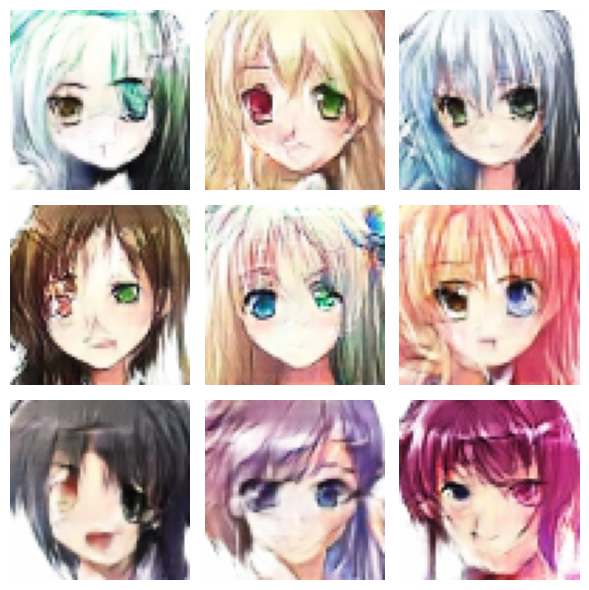

In [30]:
num_images = 9
noise = tf.random.normal((num_images, LATENT_DIM))
images = generator.predict(noise, verbose=0)

plt.figure(figsize = (6, 6))

for i in range(num_images):
    plt.subplot(3, 3, i + 1)
    plt.imshow((images[i] + 1) / 2)
    plt.axis("off")

plt.tight_layout()
plt.show()

## Compare Real vs Generated Images

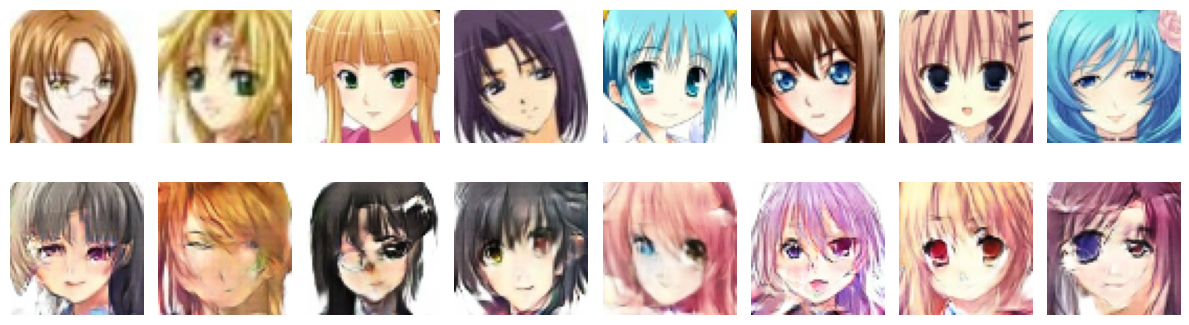

In [31]:
real_images = next(iter(dataset))

generated_images = generator.predict(
    tf.random.normal((8, LATENT_DIM)),
    verbose=0
)

plt.figure(figsize = (12, 4))

for i in range(8):

    plt.subplot(2, 8, i + 1)
    plt.imshow((real_images[i] + 1) / 2)
    plt.axis("off")
    plt.subplot(2, 8, i + 9)
    plt.imshow((generated_images[i] + 1) / 2)
    plt.axis("off")

plt.tight_layout()
plt.show()